# SCTransform

In [2]:
##系统报错改为英文
Sys.setenv(LANGUAGE = "en")
##禁止转化为因子
options(stringsAsFactors = FALSE)
##清空环境
rm(list=ls())

####设置工作路径
setwd("/Users/a1-6/Documents/projects/DL/97-bioinformatics/gene_process_for_python/single-cell-rna")
###加载所需要的包
library(Seurat)
library(tidyverse)
library(dplyr)
library(patchwork)
####清除环境，就是把环境清空了
rm(list=ls())

Loading required package: SeuratObject

Loading required package: sp


Attaching package: 'SeuratObject'


The following objects are masked from 'package:base':

    intersect, t


-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.1
v ggplot2   3.5.1     v tibble    3.2.1
v lubridate 1.9.4     v tidyr     1.3.1
v purrr     1.0.4     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [4]:
##读取10x的数据
scRNA.counts=Read10X("data/GSE152048/BC21")

###创建Seurat对象
scRNA = CreateSeuratObject(scRNA.counts ,min.cells = 3,project="os", min.features = 300)

str(scRNA)


Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. .. .. ..@ layers    :List of 1
  .. .. .. .. ..$ counts:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:14990433] 81 98 103 123 200 211 235 314 330 338 ...
  .. .. .. .. .. .. ..@ p       : int [1:6343] 0 954 1645 5154 9126 10742 13251 14020 18939 22327 ...
  .. .. .. .. .. .. ..@ Dim     : int [1:2] 20288 6342
  .. .. .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. ..@ x       : num [1:14990433] 1 1 3 1 1 1 1 9 1 1 ...
  .. .. .. .. .. .. ..@ factors : list()
  .. .. .. ..@ cells     :Formal class 'LogMap' [package "SeuratObject"] with 1 slot
  .. .. .. .. .. ..@ .Data: logi [1:6342, 1] TRUE TRUE TRUE TRUE TRUE TRUE ...
  .. .. .. .. .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. .. .. .. .. .

In [10]:
exp=as.matrix(LayerData(scRNA, assay = "RNA", layer = "counts"))

In [12]:
head(exp)

,AAACCCAAGAGATGCC-1,AAACCCAAGCCTCTCT-1,AAACCCAAGCGCTTCG-1,AAACCCAGTCACTCGG-1,AAACCCAGTGGCTAGA-1,AAACCCAGTTCCATTT-1,AAACCCATCATGGCCG-1,AAACCCATCGGAATTC-1,AAACCCATCTGAGAGG-1,AAACGAAAGTACGTCT-1,...,TTTGGTTGTGGTTTAC-1,TTTGGTTTCCCTCATG-1,TTTGTTGAGCGTATGG-1,TTTGTTGAGGCTCTAT-1,TTTGTTGAGTAGTGCG-1,TTTGTTGCAAAGACGC-1,TTTGTTGCAGACTCTA-1,TTTGTTGGTATCACCA-1,TTTGTTGTCGTTGTGA-1,TTTGTTGTCTCGGGAC-1
AL627309.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AL627309.3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AL669831.5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FAM87B,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
LINC00115,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
FAM41C,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
gene_attr=data.frame(mean=rowMeans(exp),
                     detection_rate=rowMeans(exp>0),
                     var=apply(exp,1,var))

In [16]:
gene_attr$log_mean=log10(gene_attr$mean)
gene_attr$log_var=log10(gene_attr$var)

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead."


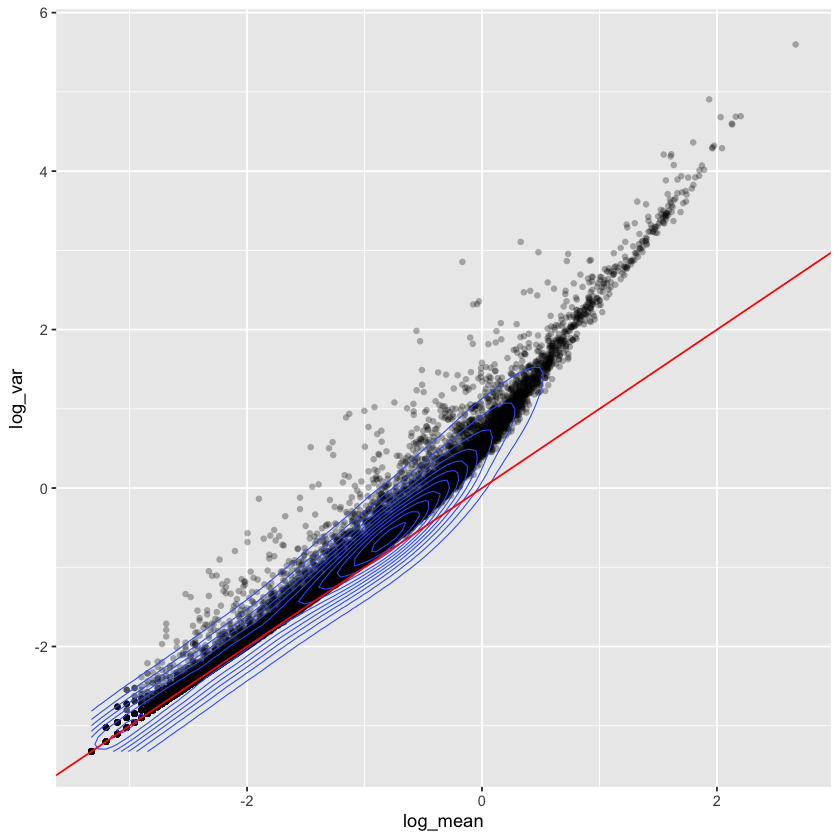

In [19]:
rownames(gene_attr)=rownames(exp)

ggplot(gene_attr,aes(log_mean,log_var))+geom_point(alpha=0.3,shape=16)+
  geom_density_2d(size=0.3)+geom_abline(intercept=0,slope=1,color="red")

[1] "mean"           "detection_rate" "var"            "log_mean"      
[5] "log_var"        "detecion_rat"

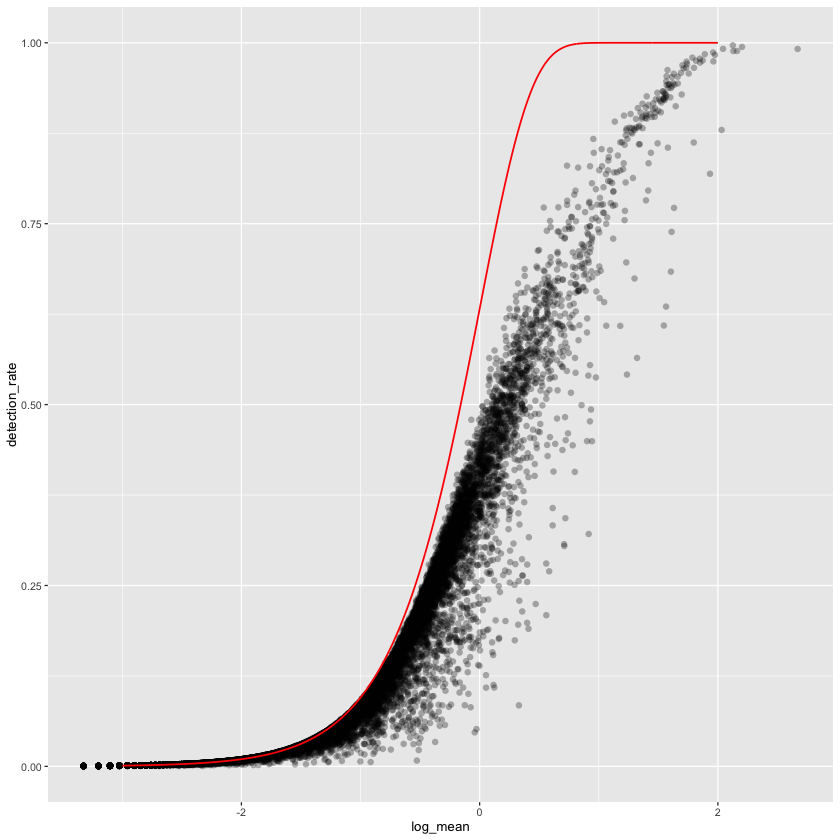

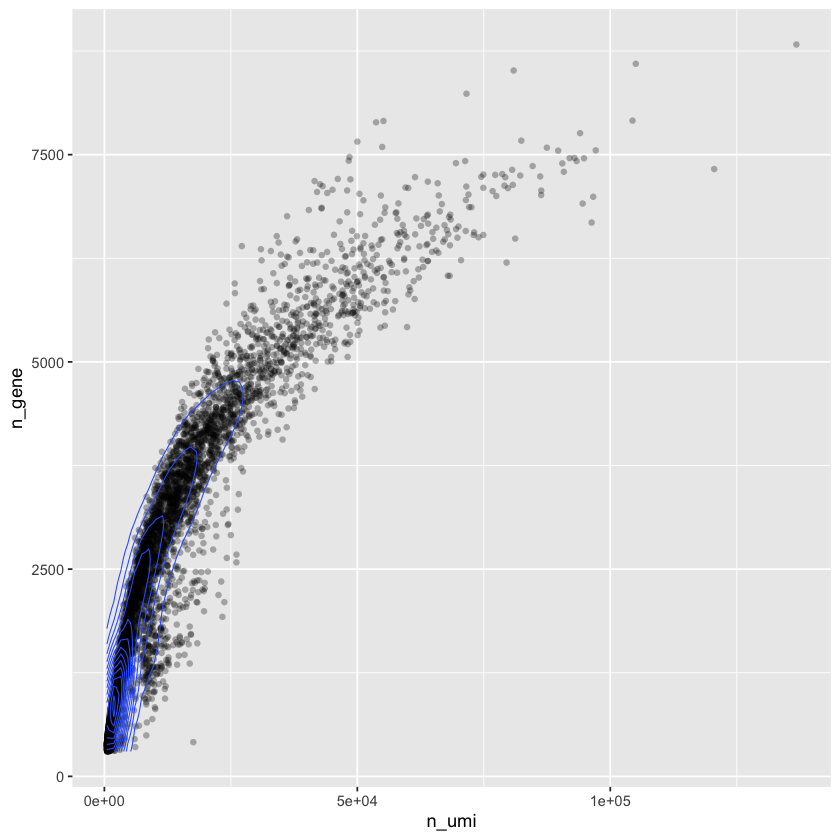

In [ ]:
gene_attr$detecion_rat=1-dpois(0,lambda = 10^(gene_attr$log_mean))

colnames(gene_attr)
x=seq(from=-3,to=2,length.out=1000)
poisson_model=data.frame(log_mean=x,detection_rate=1-dpois(0,lambda = 10^x))

ggplot(gene_attr,aes(log_mean,detection_rate))+geom_point(alpha=0.3,shape=16)+
  geom_line(data =poisson_model,color="red")+theme_gray(base_size = 8)

cell_attr=data.frame(n_umi=colSums(exp),n_gene=colSums(exp>0))
ggplot(cell_attr,aes(n_umi,n_gene))+geom_point(alpha=0.3,shape=16)+geom_density_2d(size=0.3)

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 19085 by 6342

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 6342 cells



  |======================================================================| 100%


Found 96 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 19085 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 24.68851 secs



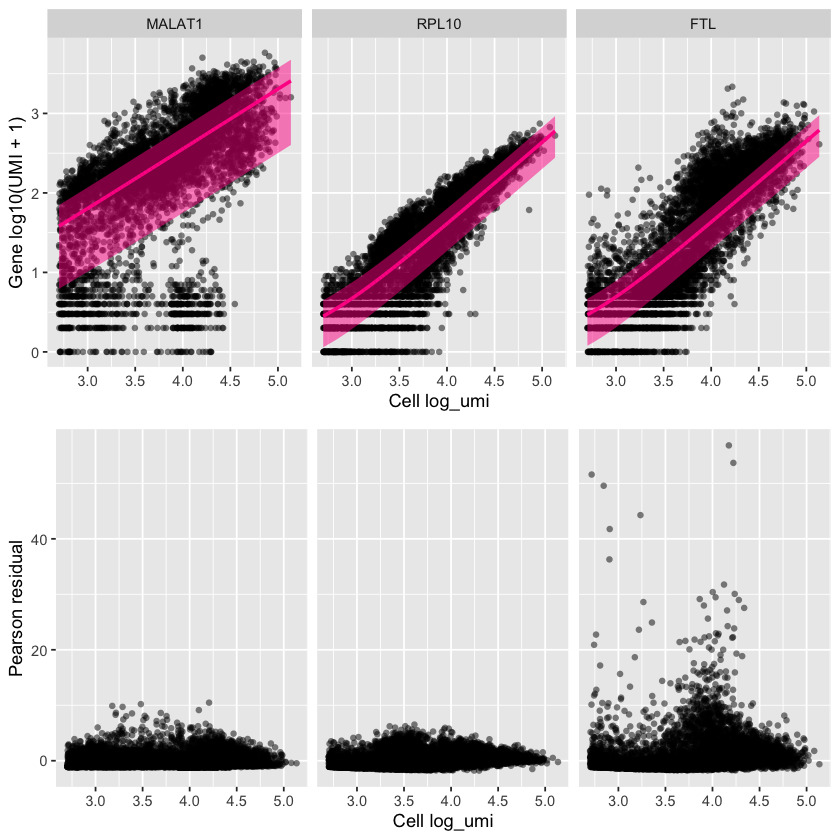

In [28]:
####run sctransform
library(future)
plan(multisession, workers = 1)  # 调整 worker 数量
options(future.globals.maxSize = 2 * 1024^3)  # 设置为 2 GiB（根据需求调整）
set.seed(44)
vst_out=sctransform::vst(exp,
                         latent_var=c("log_umi"),
                         return_gene_attr=TRUE,
                         return_cell_attr=TRUE)
sctransform::plot_model(vst_out,exp,c("MALAT1","RPL10","FTL"), plot_residual=TRUE)

In [30]:
str(scRNA)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. .. .. ..@ layers    :List of 3
  .. .. .. .. ..$ counts    :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:14990433] 81 98 103 123 200 211 235 314 330 338 ...
  .. .. .. .. .. .. ..@ p       : int [1:6343] 0 954 1645 5154 9126 10742 13251 14020 18939 22327 ...
  .. .. .. .. .. .. ..@ Dim     : int [1:2] 20288 6342
  .. .. .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. ..@ x       : num [1:14990433] 1 1 3 1 1 1 1 9 1 1 ...
  .. .. .. .. .. .. ..@ factors : list()
  .. .. .. .. ..$ data      :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:14990433] 81 98 103 123 200 211 235 314 330 338 ...
  .. .. .. .. .. .. ..@ p       : int [1:6343] 0 954 1645 5

In [34]:
head(scRNA@meta.data['nCount_RNA'])

,nCount_RNA
,<dbl>
AAACCCAAGAGATGCC-1,2570
AAACCCAAGCCTCTCT-1,1215
AAACCCAAGCGCTTCG-1,10485
AAACCCAGTCACTCGG-1,15725
AAACCCAGTGGCTAGA-1,7569
AAACCCAGTTCCATTT-1,6077


In [43]:
head(LayerData(scRNA, assay = "RNA", layer = "scale.data"))


,AAACCCAAGAGATGCC-1,AAACCCAAGCCTCTCT-1,AAACCCAAGCGCTTCG-1,AAACCCAGTCACTCGG-1,AAACCCAGTGGCTAGA-1,AAACCCAGTTCCATTT-1,AAACCCATCATGGCCG-1,AAACCCATCGGAATTC-1,AAACCCATCTGAGAGG-1,AAACGAAAGTACGTCT-1,...,TTTGGTTGTGGTTTAC-1,TTTGGTTTCCCTCATG-1,TTTGTTGAGCGTATGG-1,TTTGTTGAGGCTCTAT-1,TTTGTTGAGTAGTGCG-1,TTTGTTGCAAAGACGC-1,TTTGTTGCAGACTCTA-1,TTTGTTGGTATCACCA-1,TTTGTTGTCGTTGTGA-1,TTTGTTGTCTCGGGAC-1
AL627309.1,-0.04609868,-0.04609868,-0.04609868,-0.04609868,-0.04609868,-0.04609868,-0.04609868,-0.04609868,-0.04609868,-0.04609868,...,-0.04609868,-0.04609868,-0.04609868,-0.04609868,-0.04609868,-0.04609868,-0.04609868,-0.04609868,-0.04609868,-0.04609868
AL627309.3,-0.02069979,-0.02069979,-0.02069979,-0.02069979,-0.02069979,-0.02069979,-0.02069979,-0.02069979,-0.02069979,-0.02069979,...,-0.02069979,-0.02069979,-0.02069979,-0.02069979,-0.02069979,-0.02069979,-0.02069979,-0.02069979,-0.02069979,-0.02069979
AL669831.5,-0.13062702,-0.13062702,-0.13062702,-0.13062702,-0.13062702,-0.13062702,-0.13062702,-0.13062702,-0.13062702,-0.13062702,...,-0.13062702,-0.13062702,-0.13062702,-0.13062702,-0.13062702,-0.13062702,-0.13062702,-0.13062702,-0.13062702,-0.13062702
FAM87B,-0.04325731,-0.04325731,-0.04325731,-0.04325731,-0.04325731,-0.04325731,-0.04325731,-0.04325731,-0.04325731,-0.04325731,...,-0.04325731,-0.04325731,-0.04325731,-0.04325731,-0.04325731,-0.04325731,-0.04325731,-0.04325731,-0.04325731,-0.04325731
LINC00115,-0.14062645,-0.14062645,-0.14062645,-0.14062645,-0.14062645,-0.14062645,-0.14062645,-0.14062645,-0.14062645,-0.14062645,...,-0.14062645,-0.14062645,-0.14062645,-0.14062645,-0.14062645,-0.14062645,-0.14062645,-0.14062645,3.58629169,-0.14062645
FAM41C,-0.09247718,-0.09247718,-0.09247718,-0.09247718,-0.09247718,-0.09247718,-0.09247718,-0.09247718,-0.09247718,-0.09247718,...,-0.09247718,-0.09247718,-0.09247718,-0.09247718,-0.09247718,-0.09247718,-0.09247718,-0.09247718,-0.09247718,-0.09247718


In [51]:
length(log10(scRNA@meta.data$nCount_RNA+1))

[1] 6342

In [ ]:

####### 不使用SCTransform 使用ScaleData
################################################################
scRNA=NormalizeData(scRNA)
# ?ScaleData
scRNA=ScaleData(scRNA,features = rownames(scRNA))
regular.df=data.frame()

x=c("MALAT1","RPL10","FTL")
for (i in x) {
  tmp=data.frame(cell.log.umi=log10(scRNA@meta.data$nCount_RNA+1),
                 scale.residual=as.numeric(LayerData(scRNA, assay = "RNA", layer = "scale.data")[i,]),
                 gene=rep(i,length(log10(scRNA@meta.data$nCount_RNA+1)))
  )                  
  regular.df=rbind(regular.df, tmp)
}


Normalizing layer: counts

Centering and scaling data matrix



,cell.log.umi,scale.residual,gene
,<dbl>,<dbl>,<chr>
1,3.410102,0.6283060,MALAT1
2,3.084934,1.0517600,MALAT1
3,4.020610,0.4580744,MALAT1
4,4.196618,1.0407319,MALAT1
5,3.879096,-2.6435610,MALAT1
6,3.783761,0.2762525,MALAT1


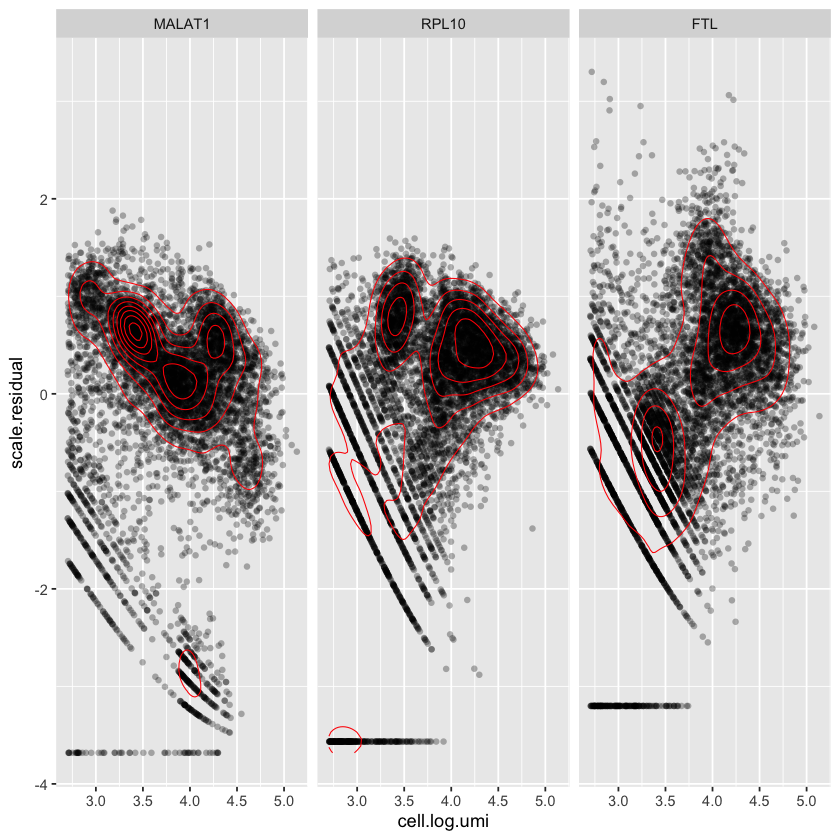

In [55]:
head(regular.df)

ggplot(regular.df,aes(cell.log.umi,scale.residual))+geom_point(alpha=0.3,shape=16)+
  geom_density_2d(size=0.3,color="red")+facet_wrap(.~factor(gene,levels=c("MALAT1","RPL10","FTL")))

In [ ]:
###############################################################################################################
##  SCTransform 完整的流程

scRNA.counts=Read10X("data/GSE152048/BC21")

###创建Seurat对象
scRNA = CreateSeuratObject(scRNA.counts ,min.cells = 3,project="os", min.features = 300)
scRNA <- PercentageFeatureSet(scRNA, pattern = "^MT-", col.name = "percent.mt")
scRNA <- SCTransform(scRNA, vars.to.regress = "percent.mt", verbose = FALSE)



`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) implementation.


Warning message in glm.nb(formula = as.formula(new_formula), data = data):
"alternation limit reached"
Warning message in glm.nb(formula = as.formula(new_formula), data = data):
"alternation limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in glm.nb(formula = as.formula(new_formula), data = data):
"alternation limit reached"
Warning message in glm.nb(formula = as.formula(new_formula), data = data):
"alternation limit reached"
Warning

In [59]:
str(scRNA@assays)

List of 2
 $ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. ..@ layers    :List of 1
  .. .. ..$ counts:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. ..@ i       : int [1:14990433] 81 98 103 123 200 211 235 314 330 338 ...
  .. .. .. .. ..@ p       : int [1:6343] 0 954 1645 5154 9126 10742 13251 14020 18939 22327 ...
  .. .. .. .. ..@ Dim     : int [1:2] 20288 6342
  .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. ..$ : NULL
  .. .. .. .. ..@ x       : num [1:14990433] 1 1 3 1 1 1 1 9 1 1 ...
  .. .. .. .. ..@ factors : list()
  .. ..@ cells     :Formal class 'LogMap' [package "SeuratObject"] with 1 slot
  .. .. .. ..@ .Data: logi [1:6342, 1] TRUE TRUE TRUE TRUE TRUE TRUE ...
  .. .. .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. .. .. ..$ : chr [1:6342] "AAACCCAAGAGATGCC-1" "AAACCCAAGCCTCTCT-1" "AAACCCAAGCGCTTCG-1" "AAACCCAGTCACTCGG-1" ...
  .. .. .. .. .. ..$ : chr "counts"
  .. .. .. ..$ dim     : int

In [60]:
######别看SCTransform只有一个单独的函数，其实它做了：NormalizeData 、ScaleData、FindVariableFeatures 的事情
########并且也支持ScaleData的vars.to.regress

##运行的结果存储在：
scRNA@assays$SCT
#或者
scRNA[["SCT"]]



SCTAssay data with 19085 features for 6342 cells, and 1 SCTModel(s) 
Top 10 variable features:
 COL1A1, COL1A2, COL3A1, SSPN, PTN, COL12A1, SPARC, C1QA, IGFBP7, SFRP4 

SCTAssay data with 19085 features for 6342 cells, and 1 SCTModel(s) 
Top 10 variable features:
 COL1A1, COL1A2, COL3A1, SSPN, PTN, COL12A1, SPARC, C1QA, IGFBP7, SFRP4 

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"


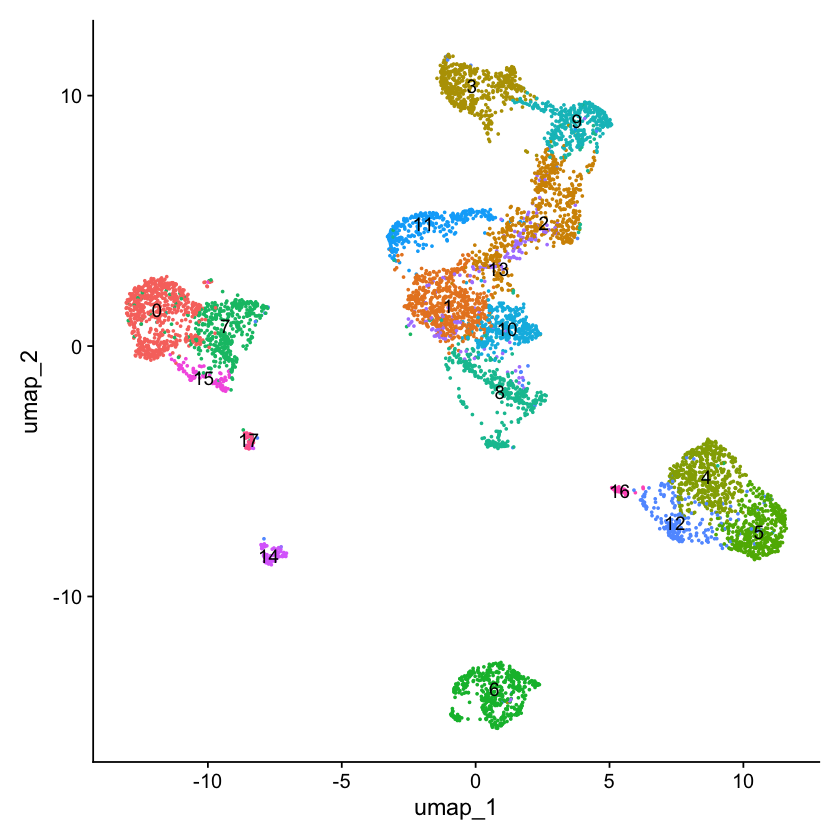

In [61]:
##降维，然后聚类

scRNA <- RunPCA(scRNA, verbose = FALSE)
scRNA <- RunUMAP(scRNA, dims = 1:30, verbose = FALSE)

scRNA <- FindNeighbors(scRNA, dims = 1:30, verbose = FALSE)
scRNA <- FindClusters(scRNA, verbose = FALSE)
DimPlot(scRNA, label = TRUE) + NoLegend()